In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
import matplotlib.cm as cm
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator, AutoLocator
import os
from scipy.stats import gaussian_kde

##### Limiting GPU Memory Growth (TensorFlow)

In [2]:
# os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
# gpus = tf.config.experimental.list_physical_devices('GPU')
# if gpus:
#     for gpu in gpus:
#         tf.config.experimental.set_memory_growth(gpu, True)
# import absl.logging
# absl.logging.set_verbosity(absl.logging.INFO)
# tf.config.experimental.set_virtual_device_configuration(gpus[0],
#     [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=200)]  # 4GB limit
# )

####  <span style="background-color:cyan">Setting matplotlib rcParams (which will work for the rest of the plot throughout the notebook)</span>

In [186]:
LARGE_SIZE = 14
MEDIUM_SIZE = 12
SMALL_SIZE = 10

params = {
    'font.family': 'serif',            # Use serif fonts like Times New Roman
    'font.size': 8,
    'font.weight': 'medium',
    'figure.figsize': (3.5, 2.5),          # Aspect ratio: 3:2
    'axes.titlesize': LARGE_SIZE,      # Title font size
    'axes.labelsize': MEDIUM_SIZE,     # Axes labels font size
    'xtick.labelsize': MEDIUM_SIZE,     # X-axis tick labels font size
    'ytick.labelsize': MEDIUM_SIZE,     # Y-axis tick labels font size
    'axes.labelweight': 'medium',
    'legend.fontsize': SMALL_SIZE,     # Legend font size
    'legend.frameon': True,            # Add a border around the legend
    'legend.loc': 'best',              # Automatically position the legend
    'lines.linewidth': 1,            # Default line width
    'lines.markersize': 6,             # Marker size
    'grid.alpha': 0.5,                 # Transparency for gridlines
    'savefig.dpi': 600,                # High DPI for publications
    'text.usetex': False,              # If True, enable LaTeX for text
    'axes.grid': False,                 # Add gridlines
    'axes.grid.axis': 'both',          # Grid on both axes
    'axes.grid.which': 'both',         # Major and minor grids
    'figure.autolayout': True,          # Avoid cutting off labels
    'axes.facecolor': 'white',         # Background color of plot area
    'axes.edgecolor': 'black',         # Edge color of axes
    'xtick.direction': 'in',           # Ticks inside plot
    'ytick.direction': 'in',           # Ticks inside plot
    'xtick.major.size': 5,             # Major tick size
    'xtick.minor.size': 3,             # Minor tick size
    'ytick.major.size': 5,             # Major tick size
    'ytick.minor.size': 3, 
    
}
plt.rcParams.update(params)
# plt.rcParams['text.usetex'] = False
# plt.rcParams['font.family'] = 'Helvetica'
# Conver and visualise any hex code
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def visualize_hex(hex_code):
    rgb = mcolors.to_rgb(hex_code)
    r, g, b = [round(x * 255) for x in rgb]

    print(f"\n Hex: {hex_code}")
    print(f" RGB: {r}, {g}, {b}")
    print(f" Red = {r}, Green = {g}, Blue = {b}")

    fig, ax = plt.subplots(figsize=(2, 1))
    ax.set_facecolor(hex_code)
    ax.text(0.5, 0.5, hex_code, ha='center', va='center', color='white' if sum(rgb) < 1.5 else 'black', fontsize=14)
    ax.set_xticks([]); ax.set_yticks([])
    plt.show()
###############to plot training history- loss vs epoch#######
def plot_training_history(history, skip=0):
    history_dict = history.history
    metrics = [m for m in history_dict.keys() if not m.startswith('val_')]
    
    for metric in metrics:
        val_metric = f'val_{metric}'
        plt.figure(figsize=(8, 5))
        
        # Slice arrays to skip initial epochs
        train_values = history_dict[metric][skip:]
        epochs_range = range(skip, skip + len(train_values))
        plt.plot(epochs_range, train_values, label=f'Training {metric}', marker='o')
        
        if val_metric in history_dict:
            val_values = history_dict[val_metric][skip:]
            plt.plot(epochs_range, val_values, label=f'Validation {metric}', marker='x')
        
        plt.xlabel('Epochs')
        plt.ylabel(metric.capitalize())
        plt.title(f'Training and Validation {metric.capitalize()} (skipping first {skip} epochs)')
        plt.legend()
        plt.grid(True)
        plt.show()
########for plotting hp trials vs epoch from keras tuner ###########
def set_clean_style(ax,major_ticks_x=10,minor_ticks_x=0.5,major_ticks_y=10,minor_ticks_y=0.5,minor_tick=None):
    import matplotlib.ticker as ticker

    ax.tick_params(axis='both', direction='in', length=5, width=1, colors='black', pad=4, which='major')
    ax.tick_params(axis='both', direction='in', length=3, width=1, colors='black', pad=8, which='minor')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(major_ticks_x))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(major_ticks_y))
    if minor_tick:
        ax.xaxis.set_minor_locator(ticker.MultipleLocator(minor_ticks_x))
        ax.yaxis.set_minor_locator(ticker.MultipleLocator(minor_ticks_y))
    
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(11)
        label.set_fontweight('medium')

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

#### <span style="background-color:cyan">Functions for Rotational & Flip Invariance AND Canonicalization</span>
- findUniqueMatrices, RotFlipInvariants, findCanonicalForm,largest_cluster_size_1D, largest_cluster_size_2D, lex_sort, cluster_sort, custom_order 

In [ ]:
def findUniqueMatrices(listOfMats):
  uniquelist = []
  for mat in listOfMats:
    if not any((mat == x).all() for x in uniquelist):  # Check if element is already in unique list
      uniquelist.append(mat)
  return uniquelist

def RotFlipInvariants(lat, rot=True, flip=True):
  invariants = []
  invariants.append(lat)
  rotMats = []
  flipMats = []
  if(lat.ndim == 2 and lat.shape[0] == lat.shape[1]):
    if(rot==True):                                    
      for i in range(1,3):
        temp = np.rot90(lat, k=i)
        rotMats.append(temp)
    invariants.extend(rotMats)
    if(flip==True):
      for matrix in invariants:
        temp = np.fliplr(matrix)
        flipMats.append(temp)
        temp = np.flipud(matrix)
        flipMats.append(temp)
      invariants.extend(flipMats)
  else:
    invariants.append(lat[::-1])
  return findUniqueMatrices(invariants)
def findCanonicalForm(arr): # returns lexicographically minimal sequence
  res = min(arr, key=lambda x: tuple(x.flatten()))
  return [res]

In [ ]:
def largest_cluster_size_1D(sequence):
    """
    Calculate the largest cluster size of 'A' in a 1D binary sequence.

    Parameters:
        sequence (str): A binary sequence composed of 'A' and 'B'.

    Returns:
        int: Size of the largest cluster of consecutive 'A' particles.
    """
    max_cluster = 0
    current_cluster = 0

    for particle in sequence:
        if particle == 1:
            current_cluster += 1
            max_cluster = max(max_cluster, current_cluster)
        else:
            current_cluster = 0  # Reset for 'B'

    return max_cluster

def largest_cluster_size_2D(grid):

    # Directions for 8-connectivity (right, down, left, up, diagonals)
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]

    # DFS function to label all cells in the island and calculate its size
    def dfs(grid, i, j, visited):
        # Mark the current cell as visited
        visited[i][j] = True

        # Start with a size of 1 for the current cell
        island_size = 1

        # Explore all 8 neighbors
        for dir_x, dir_y in directions:
            new_i, new_j = i + dir_x, j + dir_y

            # Check if the new coordinates are valid and contain a 1
            if 0 <= new_i < len(grid) and 0 <= new_j < len(grid[0]) and not visited[new_i][new_j] and grid[new_i][new_j] == 1:
                island_size += dfs(grid, new_i, new_j, visited)  # Add the size of connected cells

        return island_size

    # Function to find the size of the largest island
    def largest_island_size(grid):
        if np.all(grid == 0):
            return 0

        visited = np.zeros_like(grid, dtype=bool)  # Keep track of visited cells
        max_island_size = 0  # Initialize the maximum island size

        for i in range(len(grid)):
            for j in range(len(grid[0])):
                if grid[i][j] == 1 and not visited[i][j]:  # Found a new island
                    island_size = dfs(grid, i, j, visited)  # Get the size of the current island
                    max_island_size = max(max_island_size, island_size)  # Update max island size if needed

        return max_island_size

    # Return the size of the largest island
    return largest_island_size(grid)

In [ ]:
def lex_sort(arr, ind):

  arr = np.array(arr)
  ind = np.array(ind)

  # Convert 1D binary vector into a binary string
  if arr.ndim == 2:
    binary_strings = np.array([''.join(map(str, row)) for row in arr])
  # Convert each 2D binary matrix into a flattened binary string
  if arr.ndim == 3:
    binary_strings = np.array([''.join(map(str, row.flatten())) for row in arr])

  # Sort the indices lexicographically
  sorted_indices = np.argsort(binary_strings)

  # Reorder the array using the sorted indices
  sorted_arr = arr[sorted_indices]

  return list(sorted_arr), ind[sorted_indices]

def cluster_sort(arr, ind):

  arr = np.array(arr)

  #For 2D arrays
  if arr.ndim == 2:
    cluster_func = largest_cluster_size_1D
  #For 3D arrays
  if arr.ndim == 3:
    cluster_func = largest_cluster_size_2D

  arr = np.array(arr)
  ind = np.array(ind)

  cluster_arr = np.zeros(arr.shape[0])

  for i in range(arr.shape[0]):
    cluster_arr[i] = cluster_func(arr[i])

  sorted_indices = np.argsort(cluster_arr)

  return arr[sorted_indices], ind[sorted_indices]

In [ ]:
import copy

# custom sorting of samples based globally on the fraction and locally on lexico-min for intra-fraction
def custom_order(arr):

  for i in range(len(arr)):
    sample = arr[i]
    sample = RotFlipInvariants(sample, rot=True, flip=True) # introduce rotation and flip invariants of surface
    sample = findCanonicalForm(sample)[0]                   # only use canonical form of surface (comment to turn off)
    arr[i] = sample

  #For 2D arrays
  if arr.ndim == 2:
    sort_func = cluster_sort # sort options of lex_sort, OP_sort and cluster_sort to sort through individual fraction class
    sample_classes, inversion_indices, counts = np.unique(np.sum(arr, axis=1), return_inverse=True, return_counts=True) # set of unique fractions, their corresponding inv indices list and counts list

  #For 3D arrays
  if arr.ndim == 3:
    sort_func = cluster_sort # sort options of lex_sort, OP_sort and cluster_sort to sort through individual fraction class
    sample_classes, inversion_indices, counts = np.unique(np.sum(arr, axis=(1,2)), return_inverse=True, return_counts=True) # set of unique fractions, their corresponding inv indices list and counts list

  #print(sample_classes)

  # # for initialising lists that hold the classified forms of data and preserved old indices
  classed_arr = [[] for _ in range(len(sample_classes))]
  classed_ind = [[] for _ in range(len(sample_classes))]

  # taking each old index from inversion_indices and copying data to corresponding fraction class
  for indnum in range(len(inversion_indices)):
    index = inversion_indices[indnum]
    classed_arr[index].append(arr[indnum])
    classed_ind[index].append(indnum)

  # for initialising lists that hold the sorted forms of classified data and preserved old indices
  sorted_arr = copy.deepcopy(classed_arr)
  sorted_ind = copy.deepcopy(classed_ind)

  # running a loop through all the fraction classes to sort inside each fraction class
  for classIndex in range(len(sample_classes)):
    sorted_arr[classIndex], sorted_ind[classIndex] = sort_func(classed_arr[classIndex], classed_ind[classIndex])

  # reshaping the sorted, classified data to remove the fraction class dimension (dim1)
  reshaped_arr = [sublist for inner_list in sorted_arr for sublist in inner_list]
  reshaped_ind = [sublist for inner_list in sorted_ind for sublist in inner_list]

  return reshaped_arr, reshaped_ind

### <span style="background-color:cyan">Pruned Dataset Processing </span>

In [ ]:
pmf_data = np.load("data_final/target/pmf_surface.npy")
surface = np.load("data_final/feature/surface.npy")
polymer = np.load("data_final/feature/polymer.npy")
print(f"surface shape is:{surface.shape}\npolymer shape is:{polymer.shape}\npmf_data shape is:{pmf_data.shape}")


#### <span style="background-color:#F8E6D8">Restructuring dataset</span>

In [ ]:
ord_polymer, polymer_ind = custom_order(polymer)
polymer_strings = np.array([''.join(map(str, row)) for row in ord_polymer])

ord_surface, surface_ind = custom_order(surface)

ord_surface = np.array(ord_surface).astype(int)

surface_strings = np.array([''.join(map(str, row.flatten())) for row in ord_surface])


#### <span style="background-color:cyan">dataset preprocessing</span>

In [ ]:
###For ordering with polymer in axis-0 and surface with axis-1
# polymer_data = np.tile(polymer[:,np.newaxis,:],(1,92,1))
# surface_data = np.tile(surface[np.newaxis,:,:,:],(92,1,1,1))
# reshaped_pmf = pmf_data.transpose(1, 0, 2).reshape(92 * 92, 100)
###For ordering with polymer in axis-1 and surface with axis-0 (as previously done)
polymer_data = np.tile(polymer[np.newaxis,:,:],(92,1,1))
surface_data = np.tile(surface[:,np.newaxis,:,:],(1,92,1,1))
reshaped_pmf = pmf_data.reshape(92*92,100)
reshaped_polymer = polymer_data.reshape(92*92,40)
reshaped_surface = surface_data.reshape(92*92,20,20)
print(f"surface shape is:{reshaped_surface.shape}\npolymer shape is:{reshaped_polymer.shape}\npmf_data shape is:{reshaped_pmf.shape}")

##### <span style="background-color:#F8E6D8">Ordered data set for analysis</span>

In [ ]:
ordered_polymer_data = np.zeros(polymer_data.shape)
ordered_surface_data = np.zeros(surface_data.shape)
ordered_pmf_data = np.zeros(pmf_data.shape)

polymer_ids = 92 #90
surface_ids = 92 #10

for i in range(surface_ids):
  for j in range(polymer_ids):
    ordered_polymer_data[i,j,:] = polymer_data[surface_ind[i],polymer_ind[j],:]
    ordered_surface_data[i,j,:,:] = surface_data[surface_ind[i],polymer_ind[j],:,:]
    ordered_pmf_data[i,j,:] = pmf_data[surface_ind[i],polymer_ind[j],:]

print(ordered_polymer_data.shape)
print(ordered_surface_data.shape)
print(ordered_pmf_data.shape)

### <span style="background-color:cyan">Augmented data</span>

In [ ]:
surfacetemp = []
polymertemp = []
pmftemp = []

for i in range(len(reshaped_pmf)):
  xsample = reshaped_surface[i,:,:]
  ysample = reshaped_polymer[i,:]
  zsample = reshaped_pmf[i,:]
  xsample = RotFlipInvariants(xsample, rot=True, flip=True) # introduce rotation and flip invariants of surface
  # xsample = findCanonicalForm(xsample)                      # only use canonical form of surface (comment to turn off)
  ysample = np.tile(ysample, (len(xsample),1) )
  zsample = np.tile(zsample, (len(xsample),1) )
  surfacetemp.extend(xsample)
  polymertemp.extend(ysample)
  pmftemp.extend(zsample)

surfacetemp = np.array(surfacetemp)
polymertemp = np.array(polymertemp)
pmftemp = np.array(pmftemp)

print(surfacetemp.shape)
print(polymertemp.shape)
print(pmftemp.shape)

crude_surface = []
crude_polymer = []
crude_pmf = []

for i in range(len(pmftemp)):
  xsample = surfacetemp[i,:,:]
  ysample = polymertemp[i,:]
  zsample = pmftemp[i,:]
  ysample = RotFlipInvariants(ysample, rot=True, flip=True) # introduce invert invariant of polymer
  # ysample = findCanonicalForm(ysample)                      # only use canonical form of polymer (comment to turn off)
  xsample = np.tile(xsample, (len(ysample),1,1) )
  zsample = np.tile(zsample, (len(ysample),1) )
  crude_surface.extend(xsample)
  crude_polymer.extend(ysample)
  crude_pmf.extend(zsample)

crude_surface = np.array(crude_surface)
crude_polymer = np.array(crude_polymer)
crude_pmf = np.array(crude_pmf)

print(crude_surface.shape)
print(crude_polymer.shape)
print(crude_pmf.shape)

##### <span style="background-color:#F8E6D8">Stacking datasets</span>

In [ ]:
ydata=reshaped_pmf
xdata= np.hstack((reshaped_surface.reshape(len(reshaped_pmf),20*20), reshaped_polymer))

In [ ]:
## Augmented data
# ydata=crude_pmf
# xdata= np.hstack((crude_surface.reshape(len(crude_pmf),20*20), crude_polymer))

In [ ]:
# X_00 = xdata[:92]
X_list = []
for i in range(92,len(xdata[92:])-92,920):  
    X_list.append(xdata[i:i+920,:])
X_list = np.array(X_list)
X_01 = X_list[0]
X_02 = X_list[1]
X_03 = X_list[2]
X_04 = X_list[3]
X_05 = X_list[4]
X_06 = X_list[5]
X_07 = X_list[6]
X_08 = X_list[7]
X_09 = X_list[8]
X_100 = xdata[-92:]
np.sum(X_100[:,:400]==0)/X_100[:,:400].size

#### <span style="background-color:#ff9d3a">**Plotting selected pmf for surface vs polymer composition**</span>

In [ ]:
#Function to plot pmf data given a list of surface and polymer index. ( call plot_pmf())

def plot_pmf(pmf_data, selected_surfaces, selected_polymers, x_data=None, colors=None, save_path=None):
    """
    Function to plot PMF data for selected surfaces and polymers.
    
    Parameters: list of surfaces/plymers index
    """
    if x_data is None:
        x_data = np.linspace(0, 10, 100)
    
    if colors is None:
        colors = ['#d83034','#21A685','#8d1f17', '#ff9d3a', "#E0E417",'#0b81a2','#81CA6A',"#FF6F61","#FFB000","#4D4D4D","#1f3b4d", 'g']  
    
    
    plt.figure(figsize=(3, 3))
    
    for idx, surface_idx in enumerate(selected_surfaces):
        surf = round(surface_idx/91,1)
        for polymer_idx in selected_polymers:  
            polymer_ = round(polymer_idx/91,1)
            # label = rf'$S_{{{surf}}}, P_{{{polymer_}}}$'
            plt.plot(x_data, pmf_data[surface_idx, polymer_idx], color=colors[selected_surfaces.index(surface_idx)],
                     alpha=0.8, linewidth=2)
    
    plt.xlabel(r'$Z_{cm} (\sigma)$')
    plt.ylabel(r'$ F (k_{B}T)$')
    # handles, labels = plt.gca().get_legend_handles_labels()
    # by_label = dict(zip(labels, handles)) 
    # plt.legend(by_label.values(), by_label.keys(), loc="center left", fontsize=10, bbox_to_anchor=(1.05, 0.5),
               # ncol=2, framealpha=0)
    ax = plt.gca()
    # ax.xaxis.set_major_locator(ticker.MultipleLocator(2));ax.yaxis.set_major_locator(ticker.MultipleLocator(10))  
    # ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5));ax.yaxis.set_minor_locator(ticker.MultipleLocator(2))  
    # ax.set_ylim(0,70)
    # ax.tick_params(axis='both', direction='in', length=10, width=1, colors='black', pad=8, which='major')
    # ax.tick_params(axis='both', direction='in', length=5, width=1, colors='black', pad=8, which='minor')
    # ax.spines['bottom'].set_linewidth(1); ax.spines['left'].set_linewidth(1)
    # ax.spines['top'].set_linewidth(1); ax.spines['right'].set_linewidth(1)
    # for label in ax.get_xticklabels() + ax.get_yticklabels():
    #     label.set_fontsize(12)
    #     label.set_fontweight('medium')
    set_clean_style(ax,major_ticks_x=10,minor_ticks_x=0.5,major_ticks_y=10,minor_ticks_y=0.5,minor_tick=True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight',transparent=True)
    else:
        plt.show()

# for i in range(5,90,10):
    
selected_surfaces = [5,15,35,65,85]  
selected_polymers = [85]  
# plot_pmf(pmf_data, selected_surfaces, selected_polymers)
# plot_pmf(pmf_data, selected_surfaces, selected_polymers, save_path=f"plots_siba/pmf_plots/pmf_surface_test.pdf")

#### <span style="background-color:#ff9d3a">**Calculation of Delta F**</span>

In [ ]:
##########################################################################################################
####Calculating Different regions of PMF##################################################################
####1. Delta F 2. Positive gradient and negative gradient 3. Positive and negative second derivative######
##########################################################################################################
# plateau_region = np.where(np.abs(np.diff(pmf_data[0,0,:])) < threshold)[0]
pmf_data1 = pmf_data
window_size = 3 # Window size to decide the region of PMF profile to scan. 
prev_std = float('inf')  # Initializing std 
del_F = np.zeros((92,92)) 
positive_gradient = np.zeros((92,92))     #Positive gradient, will capture PMF transition curves
negative_gradient = np.zeros((92,92))     # Negative gradient wll capture the curve before minima.
positive_curvature = np.zeros((92,92))    # Positive second derivative, will capture the curvature at the positive gradient
negative_curvature = np.zeros((92,92))    # Negative second derivative, will capture the curvature at the curvature before the minima
wm_positive_curvature = np.zeros((92,92)) # Weighted mean, to capture the steepest region of the curvature
wm_negative_curvature = np.zeros((92,92)) # Weighted mean
min_pmf = np.zeros((92,92))
min_index = np.zeros((92,92))
min_index_value = np.zeros((92,92))
for i in range(92):
    for j in range(92):
        min_pmf[i,j] = np.min(pmf_data1[i,j,:])
        min_index[i, j] = np.argmin(pmf_data1[i, j, :])
        min_index_value[i, j] = 4.7 + 0.1 * min_index[i, j]
        for start in range(len(pmf_data1[i,j,:])-window_size):
            window = pmf_data1[i,j,start:start+window_size]
            current_std = np.std(window)
            tol = 0.1 * np.mean(window)                      # Tolerance for accepting the region to capture flat region
            if np.abs(current_std - prev_std) < tol:
                plat = (start,start+window_size)
            else:
                plat = None

            prev_std = current_std
        if plat is not None:

            for k in range(plat[0],plat[1]):
                pmf_plat = pmf_data1[i,j,k]
            pmf_max=np.mean(pmf_plat)
#             print(pmf_max)
            del_F[i,j] = pmf_max-np.min(pmf_data1[i,j,:])     # Calculating Plateu region of th profile
            gradients = np.gradient(pmf_data1[i,j,:])         # 1st derivative
            second_derivative = np.gradient(gradients)       # 2nd derivative
            positive_id = gradients > 0                      
            negative_id = gradients < 0  
            pos_w = np.abs(gradients[positive_id])           # Weight taken to be gradient values
            neg_w = np.abs(gradients[negative_id])
            positive_gradient[i,j] = np.mean(gradients[positive_id])
            negative_gradient[i,j] = np.mean(gradients[negative_id])
            positive_curvature[i,j] = np.mean(second_derivative[positive_id])
            negative_curvature[i,j] = np.mean(second_derivative[negative_id])
            wm_positive_curvature[i, j] = np.sum(second_derivative[positive_id] * pos_w) / np.sum(pos_w)
            wm_negative_curvature[i, j] = np.sum(second_derivative[negative_id] * neg_w) / np.sum(neg_w)
            # print(f"Delta_F for s{91}p{91},{del_F}")
#     print(prev_std)
    
# pmf_data[10,10,plat]
# print(plat[1])
# print(type(pmf_data1))
# np.save("min_pmf.npy",min_index_value)


#### <span style="background-color:#ff9d3a">**3D- Surface Plot**</span>

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LightSource
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from matplotlib import colors, cm
import matplotlib as mpl
fig = plt.figure(figsize=(5, 5))
avg_pmf_data = del_F.reshape(92*92,1)

surface_comps = np.linspace(0, 1, 92)
polymer_comps = np.linspace(0, 1, 92)
X, Y = np.meshgrid(surface_comps, polymer_comps)

smoothed_pmf = gaussian_filter(avg_pmf_data[::-1], sigma=1.5)

points = np.column_stack((X.ravel(), Y.ravel()))
values = smoothed_pmf.ravel()

xi = np.linspace(1, 0, 300)   
yi = np.linspace(0, 1, 300)
XI, YI = np.meshgrid(xi, yi)
ZI = griddata(points, values, (XI, YI), method='linear')
ZI = gaussian_filter(ZI, sigma=2)
ls = LightSource(azdeg=60, altdeg=85)
rgb = ls.shade(ZI, cmap=plt.cm.viridis, vert_exag=0.05, blend_mode='soft')#mpl.colormaps['YlOrRd']
norm = colors.Normalize(vmin=np.percentile(ZI, 5), vmax=np.percentile(ZI, 99))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(XI, YI, ZI,
                       facecolors=rgb,
                       alpha=1,
                       linewidth=0,
                       antialiased=False,
                       rstride=2, cstride=2)
# contour = ax.contourf(XI, YI, ZI, zdir='z', offset=ZI.min() - 12.0, norm=norm,cmap='plasma',
                      # alpha=0.9,linewidths=1.0, color='k',levels=100)  # thickness of contour lines
# ax.contour(XI, YI, ZI, zdir='z', offset=ZI.min() - 12.0,linewidths=1.0, colors='k')                    
ax.set_xlabel("Surface Composition",fontsize=10)
ax.set_ylabel("Polymer Composition",fontsize=10)
# ax.set_zlabel(r"$\Delta F$ (kJ/mol)",fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=7,pad=0)
ax.tick_params(axis='z', which='both', length=0, labelsize=0)
ax.set_zticks([])  
for label in ax.get_xticklabels():
    label.set_rotation(60)

for label in ax.get_yticklabels():
    label.set_rotation(300)
ax.set_xlim(1, 0)
ax.set_ylim(0, 1)
ax.set_zlim(0,70)
ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.grid(False)
ax.xaxis.set_visible(False)
ax.view_init(elev=28, azim=310)
fig.patch.set_alpha(0)  # Transparent background for the figure
ax.set_facecolor('none')
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(8)
    label.set_fontweight('medium')
# ax.minorticks_on()
# fig.colorbar(surf, shrink=0.5, aspect=5,anchor=(0,0.9)) 
mappable = plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.viridis)
mappable.set_array([])  # required for older versions of matplotlib

# Add colorbar
# cbar = fig.colorbar(mappable, ax=ax, shrink=0.4, pad=0.2)
# cbar.ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()
fig.savefig('plots_siba/delF_3dplot.pdf', transparent=True,dpi=600,bbox_inches='tight')

In [ ]:
# ########################################################################
# #######Visualising First and Second Derivative of PMF profile ##########
# ########################################################################
# i, j = 0, 1

# gradients = np.gradient(pmf_data1[i, j, :])
# second_derivative = np.gradient(gradients)

# positive_indices = gradients > 0
# negative_indices = gradients < 0

# plt.figure(figsize=(6, 4))
# plt.plot(pmf_data1[i, j, :], color="blue")
# # plt.plot(gradients, label="First Derivative", color="orange", linestyle="--")
# # plt.plot(second_derivative, label="Second Derivative or curvature", color="green", linestyle=":")
# plt.scatter(np.where(positive_indices)[0], second_derivative[positive_indices], color="red", label="Positive Curvature", marker="x")
# plt.scatter(np.where(negative_indices)[0], second_derivative[negative_indices], color="purple", label="Negative Curvature", marker="o")
# plt.xlabel(r"$bins$")
# plt.ylabel(r"$\Delta F$")
# plt.legend()
# plt.savefig("pmf_sample_gradient.png",dpi=300)
# plt.show()

In [ ]:
# ##############
# ###Delta F####
# ##############
data = del_F.reshape(92*92,1)
y_00 = data[:92]
y_list = []
for i in range(92,len(data)-92,920):
    y_list.append(data[i:i+920,:])
y_list = np.array(y_list)
y_01 = y_list[0]
y_02 = y_list[1]
y_03 = y_list[2]
y_04 = y_list[3]
y_05 = y_list[4]
y_06 = y_list[5]
y_07 = y_list[6]
y_08 = y_list[7]
y_09 = y_list[8]
y_10 = data[8372:]
data[91]

In [ ]:
# # polymer_fractions = np.linspace(0.1, 1.0, 92)  # Example sequence fractions from 0.1 to 1.0
# # surface_ind = 1 ## Select surface index from particular composition
# # Plotting
# # plt.figure(figsize=(3, 3))
# # (y_01.shape[0]//10)*surface_ind:((y_01.shape[0]//10)*surface_ind)+92
# # Loop through each surface to plot
# # for i in range(delta_pmf_array1.shape[0]):  # Loop over surfaces
# # plt.scatter(polymer_fractions, y_01.flatten()[92:92+92], marker='o',alpha=1, edgecolor='black',linewidth=0.8,s=60) 
# # plt.scatter(polymer_fractions, y_00.flatten()[(y_00.shape[0]//10)*surface_ind:((y_00.shape[0]//10)*surface_ind)+92], marker='o',alpha=1, edgecolor='black',linewidth=0.8,s=60) 

# plt.show()
# def plot_scatter(data, surface_ind, x_data=None, colors=None, save_path=None):
#     """
#     Function to plot del_F data for selected surfaces and all polymer composition.
    
#     Parameters:
#     """
#     if x_data is None:
#         x_data = np.linspace(0.1,1.0, 92)
    
#     if colors is None:
#         colors = ['#d83034', 'g', '#8d1f17', '#ff9d3a', '#0b81a2','#0b81a3']  
    
#     # c = plt.colormaps()[10]
#     plt.figure(figsize=(3, 3))
#     plt.scatter(x_data, data.flatten()[(data.shape[0]//10)*surface_ind:((data.shape[0]//10)*surface_ind)+92],
#                 marker='o',alpha=1, edgecolor='black',linewidth=0.8,s=60) 
    
#     ax = plt.gca()
#     ax.set_xlabel(r"$x_{p}$",fontsize=12)
#     ax.set_ylabel(r"$\Delta F ~(k_{B}T)$",fontsize=12)
#     ax.xaxis.set_major_locator(ticker.MultipleLocator(0.2))  
#     ax.yaxis.set_major_locator(ticker.MultipleLocator(10))  
#     ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))  
#     ax.yaxis.set_minor_locator(ticker.MultipleLocator(2))  
    
#     ax.tick_params(axis='both', direction='in', length=8, width=1, colors='black', pad=8, which='major')
#     ax.tick_params(axis='both', direction='in', length=5, width=1, colors='black', pad=8, which='minor')
    
#     ax.spines['bottom'].set_linewidth(1)
#     ax.spines['left'].set_linewidth(1)
#     ax.spines['top'].set_linewidth(1)
#     ax.spines['right'].set_linewidth(1)
    
    
#     plt.tight_layout()

    
#     if save_path:
#         plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     else:
#         plt.show()
# surface_ind = 0
# plot_scatter(y_100, surface_ind,save_path=f"plots_siba/delF_polymer/surface_1.0.pdf")

In [ ]:
# ##########################
# ###Box plot of Delta F ###
# ##########################
# from matplotlib.cm import get_cmap
# colors = [plt.cm.tab10(i/9) for i in range(10)]
# y = [y_00.flatten(),y_01.flatten(),y_02.flatten(),y_03.flatten(),y_04.flatten(),y_05.flatten(),y_06.flatten(),y_07.flatten(),y_08.flatten(),y_09.flatten(),y_100.flatten()]
# plt.figure(figsize=(6,4))
# bplot = plt.boxplot(y,tick_labels=[f" {i/10:.1f}" for i in range(11)],patch_artist=True)
# for patch, color in zip(bplot['boxes'],colors):
#     patch.set_facecolor(color)
# #     patch_set_edgecolors('black')
# #     patch.set_alpha(0.7)
# # plt.xticks(rotation=45)
# plt.ylabel(r"$  \nabla F$")
# # plt.xlabel()
# ax = plt.gca()
# ax.tick_params()
# ax.tick_params(axis='both', direction='in', length=8, width=1, colors='black', pad=8, which='major')
# ax.tick_params(axis='both', direction='in', length=5, width=1, colors='black', pad=8, which='minor')
# ax.spines['bottom'].set_linewidth(1)
# ax.spines['left'].set_linewidth(1)
# ax.spines['top'].set_linewidth(1)
# ax.spines['right'].set_linewidth(1)
# ax.set_xlabel(r"Fraction")
# # plt.legend()
# plt.savefig('plots_siba/Box_plot_polymer.pdf',dpi=300)
# # plt.show()

#### <span style="background-color:#ff9d3a">**Violin plot**</span>

In [ ]:
from matplotlib.cm import get_cmap
def adjacent_values(vals, q1, q3):
    upper_adjacent_value = q3 + (q3 - q1) * 1.5
    upper_adjacent_value = np.clip(upper_adjacent_value, q3, vals[-1])

    lower_adjacent_value = q1 - (q3 - q1) * 1.5
    lower_adjacent_value = np.clip(lower_adjacent_value, vals[0], q1)
    return lower_adjacent_value, upper_adjacent_value

colors = [plt.cm.tab10(i/11) for i in range(11)]
y = [y_01.flatten(),y_02.flatten(),y_03.flatten(),y_04.flatten(),y_05.flatten(),y_06.flatten(),y_07.flatten(),y_08.flatten(),y_09.flatten(),y_10.flatten()]
plt.figure(figsize=(4,3))
vplot = plt.violinplot(y)
for patch, color in zip(vplot['bodies'],colors):
    patch.set_facecolor(color)
    patch.set_edgecolors('black')
    patch.set_alpha(0.9)
plt.gca().set_xticks(np.arange(0,11),labels=[f"{i/10:.1f}" for i in range(11)])
plt.ylabel(r"$ \Delta F$")
quartiles = []
medians = []
whiskers = []

for data1 in y:
    sorted_data = np.sort(data1)
    q1, median, q3 = np.percentile(sorted_data, [25, 50, 75])
    quartiles.append((q1, q3))
    medians.append(median)
    whiskers.append(adjacent_values(sorted_data, q1, q3))

quartiles = np.array(quartiles)
medians = np.array(medians)
whiskers = np.array(whiskers)

# Extract results
quartile1, quartile3 = quartiles[:, 0], quartiles[:, 1]
whiskers_min, whiskers_max = whiskers[:, 0], whiskers[:, 1]

# Print results
# print("Quartile 1 (Q1):", quartile1)
# print("Medians:", medians)
# print("Quartile 3 (Q3):", quartile3)
# print("Whiskers Min:", whiskers_min)
# print("Whiskers Max:", whiskers_max)
inds = np.arange(1, len(medians) + 1)
plt.scatter(inds, medians, marker='o', color='white', s=30, zorder=3)
plt.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=5)
plt.vlines(inds, whiskers_min, whiskers_max, color='k', linestyle='-', lw=1)
ax = plt.gca()
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(12)
    label.set_fontweight('medium')
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['top'].set_linewidth(1)
ax.spines['right'].set_linewidth(1)
# ax.set_xlim(0,1.1)
ax.set_xlabel(r"Fraction")
# plt.legend()
plt.savefig('plots_siba/Violin_plot_surface.pdf',dpi=600)
# plt.show()

#### <span style="background-color:#ff9d3a">**Distribution plots (fraction wise)**</span>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


fractions = np.linspace(0.1, 1.0, 10)  # Fractions from 0.1 to 1.0
# colors =  ['brown', 'yellow','pink', '#FF6F61',"#7AE582"]
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'yellow','pink', '#FF6F61',"#7AE582"]
plt.figure(figsize=(4, 3))


for i, (frac, color) in enumerate(zip(fractions, colors)):
    var_name = f"y_{i+1:02d}" 
    if var_name in globals():  
        data = globals()[var_name].flatten()
        kde = gaussian_kde(data)
        x_vals = np.linspace(np.min(data), np.max(data), 1000)
        plt.plot(x_vals, kde(x_vals), label=fr"$f = {frac:.1f}$", color=color)
        plt.fill_between(x_vals, kde(x_vals),color=color,alpha=0.2)


plt.xlabel(r'$ \Delta F (k_{B}T)$')
plt.ylabel(r"P($ \Delta F $)")
# plt.legend(loc='center left', fontsize=9,framealpha=0,bbox_to_anchor=(1.01, 0.5))
ax = plt.gca()
ax.tick_params(axis='both', direction='in', length=6, width=1, colors='black', pad=4, which='major',labelsize=10)
ax.xaxis.set_major_locator(MultipleLocator(10))
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontsize(12)
    label.set_fontweight('medium')
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['top'].set_linewidth(1)
ax.spines['right'].set_linewidth(1)
plt.savefig("plots_siba/dist_del_F_surface.pdf", dpi=600)
# plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import gaussian_kde

# def plot_distribution(data, title, color='blue', highlights=None, save=False):
#     """
#     Plots the KDE.

#     """
#     x_vals = np.linspace(np.min(data), np.max(data), 1000)
#     kde = gaussian_kde(data.flatten())

#     plt.figure(figsize=(6, 4))
#     plt.plot(x_vals, kde(x_vals), 'k-', alpha=1)
#     # plt.axvline(np.mean(data.flatten()), color='r', linestyle='--')
#     plt.fill_between(x_vals, kde(x_vals), alpha=0.2, color=color)
#     if highlights:
#         for start, end, color in highlights:
#             plt.axvspan(start, end, alpha=0.2, color=color)
    
#     # plt.fill_between(30,50,alpha=0.3, color='red')

#     plt.xlabel(r"$ \Delta F~(kT)$")
#     plt.ylabel("Frequency")

#     ax = plt.gca()
#     ax.tick_params(axis='both', direction='in', length=8, width=1, colors='black', pad=8, which='major')
    
    
#     ax.spines['bottom'].set_linewidth(1.5)
#     ax.spines['left'].set_linewidth(1.5)
#     ax.spines['top'].set_linewidth(1.5)
#     ax.spines['right'].set_linewidth(1.5)
#     plt.tight_layout()
#     if save:
#         plt.savefig(save, dpi=300,bbox_inches='tight')

#     plt.show()
# plot_distribution(del_F,"del F",highlights=[(8,25,"gray"),(25,50,"red"),(50,70,"green")],save="plots_siba/distribution_DelF.pdf")

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import gaussian_kde


# data_dict = {
#     "pos_grad": positive_gradient,
#     "neg_grad": negative_gradient,
#     "pos_curvature": positive_curvature,
#     "neg_curvature": negative_curvature,
#     "Delta F": del_F
# }

# highlight_regions = {
#     "pos_grad": (0.1, 0.3),
#     "neg_grad": (-2, 0),
#     "Delta F": (10, 25)
# }

# fig, axs = plt.subplots(3, 2, layout='constrained', figsize=(8, 8))
# axs = axs.flatten()  


# for i, (title, data) in enumerate(data_dict.items()):
#     x_vals = np.linspace(np.min(data), np.max(data), 1000)
#     kde = gaussian_kde(data.flatten())
    
#     ax = axs[i]
#     ax.plot(x_vals, kde(x_vals), 'b-', alpha=1)
#     ax.axvline(np.mean(data.flatten()), color='r', linestyle='--')
#     ax.fill_between(x_vals, kde(x_vals), alpha=0.2, color=colors[i])

#     ax.set_title(title)
#     ax.tick_params(axis='both', direction='in', length=5, width=1, colors='black', pad=8, which='major')

    
#     if title in highlight_regions:
#         ax.axvspan(*highlight_regions[title], alpha=0.2)


# axs[-1].axis("off")

# plt.savefig("plots_siba/distribution.png", dpi=300)
# # plt.show()


#### Plotting epochs

In [194]:

def moving_average(data, window):
    return np.convolve(data, np.ones(window)/window, mode='valid')

def plot_history_metrics(
    history,
    metric='loss',
    data_types=('train', 'val'),   # any combo: ('train',), ('val',), ('train', 'val')
    min_epoch=None,
    smooth_window=None,
    savepath=None,
    figsize=(4, 3)
):
    """
    Plot one or more metric types (e.g., train/val/test) from history.

    Parameters:
    - history: model.fit() history or dict
    - metric: base metric name, e.g. 'loss', 'mae', 'accuracy'
    - data_types: tuple of str, e.g. ('train',), ('val',), ('train','val')
    - max_epoch: int, truncate epochs
    - smooth_window: int, apply moving average
    - savepath: str, file path to save
    - figsize: tuple, default (4, 3)
    """

    if isinstance(history, dict):
        class DummyHistory: pass
        h = DummyHistory()
        h.history = history
        history = h

    hist = history.history
    colors = {'train': 'blue', 'val': 'orange', 'test': 'green'}

    plt.figure(figsize=figsize)

    for dtype in data_types:
        key = metric if dtype == 'train' else f'{dtype}_{metric}'
        if key not in hist:
            print(f"⚠️ Skipping: '{key}' not found in history.")
            continue
        
        values = np.array(hist[key])
        epochs = np.arange(1, len(values) + 1)

        # Truncate
        if min_epoch:
            values = values[min_epoch:]
            epochs = epochs[min_epoch:]
        # plt.plot(epochs, values, lw=1.2, color=colors.get(dtype, 'green'), alpha=0.7)
        # Smooth
        if smooth_window and smooth_window < len(values):
            values = moving_average(values, smooth_window)
            epochs = epochs[:len(values)]

        label = f"{dtype.capitalize()} {metric.capitalize()}"
        plt.plot(epochs, values, lw=2, color=colors.get(dtype, None), label=label)

    plt.xlabel("Epoch", fontsize=12, fontweight='medium')
    plt.ylabel(metric.capitalize(), fontsize=12, fontweight='medium')
    plt.legend(fontsize=10, frameon=False)

    ax = plt.gca()
    # set_clean_style(ax)
    ax.set_ylim(0,1)
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=600)
    # plt.show()


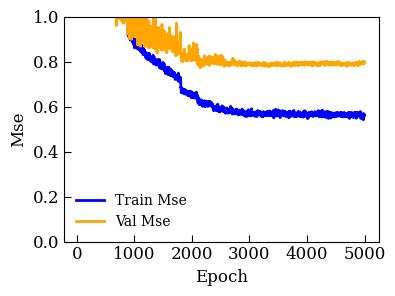

In [201]:
forward_history_cnn = np.load("my_models_siba/history/DNN/canonical_forward_history_DNN_mod.npy",allow_pickle='TRUE').item()
# forward_history_cnn = np.load(f"scratch_alen/final/history/DNN/canonical_forward_history.npy",allow_pickle='TRUE').item()
plot_history_metrics(
    forward_history_cnn,
    metric='mse',
    data_types=('train', 'val'),
    min_epoch=25,
    smooth_window=5,
    savepath=None
)

In [ ]:
#Mean Error vs PMF Bin
mean_abs_error_per_bin = np.mean(np.abs(y_pred - y_test), axis=0)
plt.plot(mean_abs_error_per_bin)
plt.title("Mean Absolute Error per PMF Bin")
plt.xlabel("PMF Bin Index")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.show()


## <span style="background-color:#ff9d3a">**Machine learning predictions for $\Delta F$**</span>

In [ ]:
from timeit import default_timer as timer

# Displays stats (time and mse) every 'skip_epochs' number of epochs
class LogsCallback(tf.keras.callbacks.Callback):

    def __init__(self, skip_epochs):
        super().__init__()
        self.skipsteps = skip_epochs
        self.epoch = 0
        self.starttime = 0.0
        self.endtime = 0.0
        self.timebd = '0 sec'

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch = epoch

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.skipsteps == 0: #executes statements below after every 'skip_epochs' number of epochs
          if epoch != 0:
            self.endtime = timer()                                     # invoke end timer after current block of epochs has finished
            self.timesec = int((self.endtime - self.starttime)%60)     # time passed for training each block of epochs (split into seconds and minutes)
            self.timemin = int((self.endtime - self.starttime)/60.0)   # time passed for training each block of epochs (split into seconds and minutes)
            self.timebd = str(self.timemin) + 'min. ' + str(self.timesec) + 'sec.' # time passed as a string to be displayed
          print('Epoch: ' + str(self.epoch) + ',\t val_mse: ' + str(logs['val_mse']) + ',\t time for prev. ' +str(self.skipsteps)+' epochs: '+self.timebd)
          self.starttime = timer() # restart start timer to indicate beginning of next block

logs_cb = LogsCallback(skip_epochs = 100)

checkpoint = keras.callbacks.ModelCheckpoint("scratch_alen/models/fDNN_profile_siba.keras", monitor='val_mae', verbose=0,
    save_best_only=True, mode='auto')

def lr_scheduler(epoch, lr):
  lr = 0.00001
  #if(epoch<10000 and epoch > 0):
  #  exp = np.ceil(np.log10(epoch))
  #  lr = 0.1*10**(-1*exp)
  if(epoch>10000):
    if(epoch%1000) == 0:
        vb = int(epoch/1000)
        lr = 0.00001/(vb+1.0)
  return lr

lrs_cb = keras.callbacks.LearningRateScheduler(lr_scheduler, verbose=0)
class CustomCallback(tf.keras.callbacks.Callback):
    loss_metric = ''
    val = 0.0
    def __init__(self, loss_metric, val):
        self.loss_metric = loss_metric
        self.val = val
    def on_epoch_end(self, epoch, logs=None):
        if logs.get(self.loss_metric) <= self.val:
            self.model.stop_training = True
custom_cb = CustomCallback('val_loss', 0.05)

### <span style="background-color:cyan">Splitting datasets</span>

In [ ]:
from sklearn.model_selection import train_test_split
X_train_full, X_test, y_train_full, y_test = train_test_split(xdata, ydata,test_size=0.2,random_state=40)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full,random_state=40)

In [ ]:
keras.backend.clear_session()
tf.random.set_seed(40)

In [ ]:
import json
import os
import keras_tuner as kt

def build_model(hp):
    """Function for keras tuner using RandomisedSeach"""

    num_layers = hp.Int("num_layers",min_value=1, max_value=3, step=1,default=2)    ### Number of layers
    # num_neuron = hp.Int("num_neuron",min_value=16,max_value=300) ### Number of neurons
    
    learning_rate = hp.Float("learning_rate",min_value=1e-4,max_value=1e-2,sampling="log")   ## Learnin rate 
    optimizer = hp.Choice("optimizer",values=["sgd","Adam","RMSprop"])
    # activation =  hp.Choice("activation",values=["relu","leaky_relu"])
    if optimizer == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer == "Adam":
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    input_ = keras.Input(shape=(440,))
    x = input_

    ## adding hidden layers dynamically, from 1 to 5
    for i in range(num_layers):
        
        x = keras.layers.Dense(units=
                               hp.Int(f"n_neurons_{i}", min_value=50, max_value=256, step=16),
                              activation=keras.layers.LeakyReLU())(x)
#        x = keras.layers.Dropout(hp.Float(f"droupout_{i}", 0.1, 0.5, step=0.1))(x)
    ## Output layer
    output_ = keras.layers.Dense(100)(x)
    model_tune = keras.Model(inputs=[input_],outputs=[output_])

    ## Compiling the model
    model_tune.compile(optimizer=optimizer
    , loss="mae", metrics=["mse","mae"],)
    return model_tune

In [ ]:
# from keras_tuner import Hyperband
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, restore_best_weights=True)
# Reload the tuner from the saved directory
# tuner = Hyperband.load("new_tunning")
tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=200,
    executions_per_trial=2,
    directory="new_tunning",
    project_name="RandomSearch_tunning",
    seed=40,overwrite=True
    )
# tuner.reload()
tuner.search(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=200,
    batch_size=64,verbose=2,callbacks=[early_stopping]
 

In [ ]:
top3_params = tuner.get_best_hyperparameters(num_trials=3)
top3_params[0].values

In [ ]:
best_model.fit(X_train_full,y_train_full,validation_data=(X_valid,y_valid),epochs=1000,verbose=2)

In [ ]:
# # x = [-10,-9,-8,-3,0,1,4,6]
# x = np.linspace(-10,10,50)
# f_x = x**3
# leaky_relu = keras.activations.relu(f_x)
# plt.plot(x,f_x,"r--")
# plt.plot(x,leaky_relu,"k--")

# #visualising different initializers, which is being used by kernels and bias initialization
# initializers = {
#     "RandomNormal": keras.initializers.RandomNormal(mean=0.0, stddev=1.0),
#     "RandomUniform": keras.initializers.RandomUniform(minval=-1, maxval=1),
#     "GlorotNormal": keras.initializers.GlorotNormal(),
#     "GlorotUniform": keras.initializers.GlorotUniform(),
#     "HeNormal": keras.initializers.HeNormal(),
#     "HeUniform": keras.initializers.HeUniform(),
#     "LecunNormal": keras.initializers.LecunNormal(),
#     "LecunUniform": keras.initializers.LecunUniform(),
# }

# num_samples = 300
# fig, axes = plt.subplots(2, 4, figsize=(15, 8))
# axes = axes.flatten()

# for i, (name, initializer) in enumerate(initializers.items()):
#     weights = initializer(shape=(num_samples,)).numpy()  # Generate weights
#     axes[i].hist(weights, bins=30, alpha=0.7, color="blue", edgecolor="black")
#     axes[i].set_title(name)
#     axes[i].set_xlabel("Weight Value")
#     axes[i].set_ylabel("Frequency")

# plt.tight_layout()
# plt.show()

# # Regularizers
# # keras.layers.Dense(300, activations="leaky_relu",kernel_regularizer=keras.regularizers.l1_l2(l1=1e-5,l2=1e-4)

## Hyperparameter optimization

In [ ]:
###
#Bayesian optimization (n_neuron, n_layer, Batch_size, lr, regularization)

# import keras_tuner as kt

# def build_model(hp):
#     input_layer = keras.layers.Input(shape=(440,))
#     num_layers = hp.Int("num_layers",min_value=2, max_value=5, step=1)
      # num_neuron = hp.Int("num_neuron",min_value=16,max_value=300)
# learning_rate = hp.Float(
#     x = keras.layers.Dense(
#         units=hp.Int("n_neuron_1",min_value=100, max_value=300, step=50),
#         activation=keras.layers.LeakyReLU(),
#         kernel_regularizer=keras.regularizers.L2(hp.Float("l2_reg_1",1e-5,1e-2,sampling="log")))(input_layer)

#     ## adding hidden layers dynamically, from 1 to 5
#     for i in range(2,num_layers + 1):
#         x = keras.layers.Dense(
#             units=hp.Int(f"n_neurons_{i}", min_value=50, max_value=200, step=25),
#             activation=keras.layers.LeakyReLU(),
#             kernel_regularizer=keras.regularizers.L2(hp.Float(f"l2_reg_{i}", 1e-5, 1e-2, sampling="log"))
#         )(x)
#         x = keras.layers.Dropout(hp.Float(f"droupout_{i}", 0.1, 0.5, step=0.1))(x)
#     ## Output layer
#     output_ = keras.layers.Dense(100)(x)
#     model_tunning = keras.Model(inputs=[input_layer],outputs=[output_])

#     ## Compiling the model
#     model_tunning.compile(optimizer=keras.optimizers.Adam(
#         learning_rate=hp.Choice("learning_rate", values=[1e-2, 1e-3,1e-4,1e-5])
#     ), loss="mse", metrics=["mse","mae"],)
#     return model_tunning
# def build_model(hp):
#     input_layer = layers.Input(shape=(440,))  # Input shape

#     # Tune the number of layers
#     num_layers = hp.Int("num_layers", min_value=2, max_value=5, step=1)

#     # Define first layer
#     x = layers.Dense(
#         units=hp.Int("n_neurons_1", min_value=100, max_value=300, step=50),
#         activation=keras.layers.LeakyReLU(),
#         kernel_regularizer=regularizers.L2(hp.Float("l2_reg_1", 1e-5, 1e-2, sampling="log"))
#     )(input_layer)

#     # Add hidden layers dynamically
#     for i in range(2, num_layers + 1):
#         x = layers.Dense(
#             units=hp.Int(f"n_neurons_{i}", min_value=50, max_value=200, step=25),
#             activation=keras.layers.LeakyReLU(),
#             kernel_regularizer=regularizers.L2(hp.Float(f"l2_reg_{i}", 1e-5, 1e-2, sampling="log"))
#         )(x)
#         x = layers.Dropout(hp.Float(f"dropout_{i}", 0.1, 0.5, step=0.1))(x)

#     # Output layer
#     output_layer = layers.Dense(100)(x)

#     model = keras.Model(inputs=[input_layer], outputs=[output_layer])

#     # Compile the model
#     model.compile(
#         optimizer=keras.optimizers.Adam(
#             learning_rate=hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4, 1e-5])
#         ),
#         loss="mse",
#         metrics=["mse", "mae"],
#     )

    # return model

# tuner = kt.BayesianOptimization(
#     build_model,
#     objective="val_loss",
#     max_trials=100,
#     executions_per_trial=2,
#     directory="DNN_tunning",
#     project_name="Bayesian_tunning"
# )

# # batch_size = [16, 32, 64, 128]


# early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=100, restore_best_weights=True)

# tuner.search(
#     X_train, y_train,  
#     validation_data=(X_valid, y_valid),  
#     epochs=5000,
#     batch_size=32,  
#     callbacks=[early_stopping]
# )

# best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# import json
# with open("best_hyperparameters.json", "w") as f:
#     json.dump(best_hps.values, f, indent=4)

# print("Best Hyperparameters:", best_hps.values)
# import json
# with open("DNN_tuning/best_hyperparameters.json", "r") as f:
#     best_hps = json.load(f)

# Create a new HyperParameters object
# hp = kt.HyperParameters()
# for key, value in best_hps.items():
#     hp.Fixed(key, value)  # Fix each hyperparameter to its best value

# t_model = tuner.hypermodel.build(hp)
# history = t_model.fit(
#     X_train, y_train,
#     validation_data=[X_valid, y_valid],
#     epochs=100000,
#     batch_size=32,
#     callbacks=[early_stopping, logs_cb],verbose=0
# )

# best_model.save("best_model.keras")

# with open("training_history.json", "w") as f:
#      json.dump(history.history, f, indent=4)

# DNN_final = keras.models.load_model("DNN_tuning/best_model.keras")

# # Predict
# predictions = DNN_final.predict(X_test)

## Hyperparameter tuning using Bayesian Optimization

In [ ]:
# from sklearn.model_selection import cross_val_score
# from keras.optimizers import Adam, SGD, RMSprop, Adadelta, Adagrad, Adamax, Nadam, Ftrl
# from math import floor
# from sklearn.metrics import mean_squared_error
# from bayes_opt import BayesianOptimization
# from keras.layers import LeakyReLU
# LeakyReLU = LeakyReLU(negative_slope=0.1)
# import warnings

In [ ]:
# import tensorflow.keras as keras
# from tensorflow.keras.models import Model
# from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adadelta, Adagrad, Adamax, Nadam, Ftrl
# from tensorflow.keras.callbacks import EarlyStopping
# from scikeras.wrappers import KerasRegressor
# from sklearn.model_selection import cross_val_score, KFold

# def nn_cl_bo(neurons, activation, optimizer, learning_rate, batch_size, epochs):
#     # Use optimizer names instead of indices
#     optimizerD = [ Adam(learning_rate=learning_rate), 
#                    SGD(learning_rate=learning_rate),
#                    RMSprop(learning_rate=learning_rate), 
#                    Adadelta(learning_rate=learning_rate),
#                    Adagrad(learning_rate=learning_rate), 
#                    Adamax(learning_rate=learning_rate),
#                    Nadam(learning_rate=learning_rate), 
#                   Ftrl(learning_rate=learning_rate)]

#     activationL = ['relu', 'sigmoid', 'softplus', 'softsign', 'tanh', 'selu',
#                    'elu', 'exponential', 'LeakyReLU']

#     neurons = round(neurons)
#     activation = activationL[round(activation)]  # Round activation index
#     batch_size = round(batch_size)
#     epochs = round(epochs)

#     def nn_cl_fun():
#         # Define the neural network
#         input_layer = keras.layers.Input(shape=(440,))  # Ensure your data has 440 features
#         hidden1 = keras.layers.Dense(neurons, activation=activation)(input_layer)
#         hidden2 = keras.layers.Dense(neurons, activation=activation)(hidden1)
#         output_layer = keras.layers.Dense(100)(hidden2)  # 100 output units, adjust as needed

#         model = keras.models.Model(inputs=input_layer, outputs=output_layer)
#         model.compile(loss='mse', optimizer=optimizerD[optimizer], metrics=['mae'])  # Use string optimizer names
#         return model

#     # Early stopping configuration
#     es = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=0, patience=200)

#     # Wrap the model in a KerasRegressor for cross-validation
#     nn = KerasRegressor(build_fn=nn_cl_fun, epochs=epochs, batch_size=batch_size, verbose=0)

#     # Perform k-fold cross-validation
#     kfold = KFold(n_splits=5, shuffle=True, random_state=123)
#     score = cross_val_score(nn, X_train, y_train, scoring='neg_mean_squared_error', cv=kfold, fit_params={'callbacks': [es]}).mean()

#     return -score  # Return negative score as lower MSE is better in this case


In [ ]:
# params_nn ={
#     'neurons': (50, 300),
#     'activation':(0, 9),
#     'optimizer':(0,7),
#     'learning_rate':(0.0001, 0.001),
#     'batch_size':(32, 256),
#     'epochs':(100, 5000)
# }
# nn_bo = BayesianOptimization(nn_cl_bo, params_nn, random_state=111)
# nn_bo.maximize(init_points=25, n_iter=4)

In [ ]:
# def nn_bo(ad_alpha, ad_beta1, ad_beta2, act_alpha, lambtha, neurons_A2, neurons_A3, dropout_1, dropout_2):
    

#     ad_alpha = 10 ** ad_alpha  
#     act_alpha = 10 ** act_alpha 
#     lambtha = 10 ** lambtha  
    
   
#     neurons_A2 = int(neurons_A2)
#     neurons_A3 = int(neurons_A3)
    
    
#     kernel_regularizer = keras.regularizers.l2(float(lambtha))
    
    
#     optimizer = keras.optimizers.Adam(learning_rate=float(ad_alpha), beta_1=float(ad_beta1), beta_2=float(ad_beta2))
    
    
#     activation_function = keras.layers.LeakyReLU(alpha=act_alpha)
    
    
#     forward_input = keras.layers.Input(shape=(440,), name="A1")
    
#     A2 = keras.layers.Dense(neurons_A2, activation=activation_function, name="A2", kernel_regularizer=kernel_regularizer)(forward_input)
#     dropout_1_layer = keras.layers.Dropout(float(dropout_1))(A2)
    
#     A3 = keras.layers.Dense(neurons_A3, activation=activation_function, name="A3", kernel_regularizer=kernel_regularizer)(dropout_1_layer)
#     dropout_2_layer = keras.layers.Dropout(float(dropout_2))(A3)
    
#     A4 = keras.layers.Dense(100, name="A4")(dropout_2_layer)  # Output Layer
    
  
#     fDNN_test = keras.models.Model(forward_input, A4)
    
   
#     fDNN_test.compile(optimizer=optimizer, loss='mse', metrics=['mse', 'mae'])
    
  
#     history = fDNN_test.fit(X_train, y_train, epochs=5000, batch_size=64, verbose=0, validation_data=(X_valid, y_valid))
    
   
#     val_loss = np.mean(history.history['val_mse'][-5:]) 
    
#     return -val_loss 


# pbounds = {
#     'ad_alpha': (-5, -2),  
#     'ad_beta1': (0.85, 0.99),
#     'ad_beta2': (0.90, 0.99),
#     'act_alpha': (-4, -3),  
#     'lambtha': (-5, -2),  
#     'neurons_A2': (100, 400),
#     'neurons_A3': (50, 300),
#     'dropout_1': (0.05, 0.5),
#     'dropout_2': (0.05, 0.5),
# }


# optimizer = BayesianOptimization(
#     f=nn_bo,
#     pbounds=pbounds,
#     random_state=42,verbose=2
# )

# optimizer.maximize(init_points=5, n_iter=20)


# best_params = optimizer.max
# print("Best Hyperparameters:", best_params)


In [ ]:
# param = best_params['params']
# act_alpha = 10 ** param['act_alpha']
# ad_alpha = 10 ** param['ad_alpha']
# ad_beta1 = param['ad_beta1']
# ad_beta2 = param['ad_beta2']
# dropout_1 = param['dropout_1']
# dropout_2 = param['dropout_2']
# lambtha = 10 ** param['lambtha']
# neuron_A2 = int(round(param['neurons_A2']))
# neuron_A3 = int(round(param['neurons_A3']))
# param
# act_alpha =  10 ** -1.283878054124271
# ad_alpha =  10 ** -4.041804012815852
# ad_beta1 = 0.9070552123955717
# ad_beta2 = 0.9713713135369371
# dropout_1 = 0.3643874804104811
# dropout_2 = 0.07189267639850719
# lambtha = 10 ** -4.647870690386108
# neuron_A2 = int(round(353.879163441463))
# neuron_A3 = int(round(57.43468441647516))

In [ ]:
# test_hist = final_model.fit(X_train, y_train, validation_data=(X_valid, y_valid), 
#                           epochs=5000, batch_size=64, callbacks=[logs_cb], verbose=0)

In [ ]:
# # best_model = tuner.hypermodel.build(best_hps)

# # # Train the model
# # history = best_model.fit(
# #     X_train, y_train,
# #     validation_data=(X_valid, y_valid),
# #     epochs=100, 
# #     batch_size=32,
# #     callbacks=[early_stopping]
# # )
# # best_model.save("best_model.keras")

# # with open("training_history.json", "w") as f:
# #     json.dump(history.history, f, indent=4)
# best_model = tuner.hypermodel.build(best_hps)
# history = best_model.fit(
#     X_train, y_train,
#     validation_data=[X_valid, y_valid],
#     epochs=100000,
#     batch_size=32,
#     callbacks=[early_stopping]
# )
# best_model.save("best_model.keras")

In [ ]:
# opt = keras.optimizers.RMSprop(learning_rate=0.001)
# model.compile(loss='mse',optimizer=opt,metrics=['mse','mae'])

# checkpoint_cb = keras.callbacks.ModelCheckpoint("my_model.h5",save_best_only=True)
# # earlystopping_cb = keras.callbacks.EarlyStopping(patience =10)
# # model = keras.models.load_model("my_model.h5")
# #python3 training.py --batch_size 64 --epochs 20 --xdata xdata.npy --ydata ydata.npy ##########
# class LayerOutputCallback(keras.callbacks.Callback):
#     def __init__(self, model, input_):
#         super().__init__()
#         self.model = model
#         self.input_ = input_
#         self.layer_output = [layer.output for layer in model.layers]
#         self.model_output = keras.Model(inputs=[model.input],outputs=[self.layer_output])
#     def on_epoch_end(self,epoch,logs=None):
#         outputs = self.model_output.predict(self.input_,verbose=0)
#         print(f"\n Epoch {epoch+1} - Layer output\n")
#         for i, output in enumerate(outputs):
#             #if you want to visualise activation functions output at each layer, then
#             #plt.subplot(1, len(outputs), i+1)
#             plt.hist(output.flatten(),alpha=0.7,bins=20,color="blue")
#             print(f"Layer {i+1} ({self.model.layers[i].name}) Output shape {outputs.shape}")
#             print(f"Sample output {outputs[0][:5]}")
#         plt.tight_layout()
#         plt.show()

In [ ]:
# layer_output = [layer.output for layer in model.layers]
# model_output = keras.Model(inputs=[model.input],outputs=[layer_output])
# outputs = model_output.predict(X_train[:1])
# # plt.figure(figsize=(4,6))
# fig,axes = plt.subplots(1,6,figsize=(15,3))

# axes[0].imshow(outputs[0][0,:400].reshape(20,20))
# axes[1].plot(outputs[1].flatten())
# axes[2].plot(outputs[2].flatten())
# axes[3].plot(outputs[3].flatten())
# axes[4].plot(outputs[4].flatten())
# # axes[5].plot(outputs[5].flatten())
# plt.tight_layout()
# plt.show()

In [ ]:
# plt.plot(history.history['mse'][1000:],'k-')
# plt.plot(history.history['val_mse'][1000:],'r-')

In [ ]:
# len(model.weights)

In [ ]:
# import seaborn as sns
# I, h1, h2, o = model.layers
# w1, b1 = h1.get_weights()
# w2, b2 = h2.get_weights()
# sns.heatmap(np.where(w1>0,1,0),cmap="coolwarm", center=0)

In [ ]:
# plt.hist(w2[:,:].flatten())

In [ ]:
# plt.hist(w1[:,:].flatten())

In [ ]:
# from sklearn.decomposition import PCA
# import plotly.express as px
# from sklearn.manifold import TSNE
# # Example: Flatten weights if needed
# weights = w1.reshape(w1.shape[0], -1)

# # Apply PCA
# # pca = PCA(n_components=2)
# # weights_2d = pca.fit_transform(flattened_weights)

# # # Scatter plot of weights
# # plt.figure(figsize=(8, 6))
# # plt.scatter(weights_2d[:, 0], weights_2d[:, 1], c='blue', alpha=0.7)
# # plt.title("2D PCA of Hidden Layer Weights")
# # plt.xlabel("Principal Component 1")
# # plt.ylabel("Principal Component 2")
# # plt.show()
# tsne = TSNE(n_components=3,perplexity=2)
# weights_3d = tsne.fit_transform(weights)  # Reshaping as required

# # Create an interactive 3D scatter plot using plotly
# fig = px.scatter_3d(
#     x=weights_3d[:, 0],
#     y=weights_3d[:, 1],
#     z=weights_3d[:, 2],
#     title="3D t-SNE of Neural Network Weights",
#     labels={"x": "t-SNE Dim 1", "y": "t-SNE Dim 2", "z": "t-SNE Dim 3"}
# )
# fig.show()

In [ ]:
# y_predict = model.predict(X_test)

In [ ]:
# import numpy as np

# # Dummy data (replace with actual data)
# surface = np.random.rand(92, 20, 20)  # (92, 20, 20)
# polymer = np.random.rand(92, 40)      # (92, 40)
# pmf_data = np.random.rand(92, 92, 100)  # (92, 92, 100)

# # Create polymer dataset (92 polymers repeated for each surface)
# polymer_data = np.tile(polymer, (92, 1, 1))  # (92, 92, 40)

# # Create surface dataset (92 surfaces repeated for each polymer)
# surface_data = np.tile(surface[:, np.newaxis, :, :], (1, 92, 1, 1))  # (92, 92, 20, 20)

# # Reshape for ML training
# reshaped_pmf = pmf_data.reshape(92 * 92, 100)  # (8464, 100)
# reshaped_polymer = polymer_data.reshape(92 * 92, 40)  # (8464, 40)
# reshaped_surface = surface_data.reshape(92 * 92, 400)  # (8464, 400)

# # Print shapes
# print(f"Surface shape: {reshaped_surface.shape}")
# print(f"Polymer shape: {reshaped_polymer.shape}")
# print(f"PMF shape: {reshaped_pmf.shape}")

# # Final dataset for ML
# X = np.hstack((reshaped_polymer, reshaped_surface))  # (8464, 440)
# y = reshaped_pmf  # (8464, 100)

# # Save dataset
# np.save("ml_dataset.npy", np.hstack((X, y)))

# # Optional: Save as CSV
# np.savetxt("ml_dataset.csv", np.hstack((X, y)), delimiter=",", fmt="%.6f")


In [ ]:
# surface_1 = np.random.rand(92,20,20)
# polymer_1 = np.random.rand(92,40)
# polymer_test = np.tile(polymer[:,np.newaxis,:],(1,92,1))
# surface_test = np.tile(surface[np.newaxis,:,:,:],(92,1,1,1))

In [ ]:
# import matplotlib.cm as cm  # Import colormap
# # plt.style.use('/Users/sibasankarpanigrahy/Documents/ML:AI/surfacepoly_results/scripts/thesis.mplstyle')
# # Assuming pmf_data is of shape (10, 90, 100)
# pmf_data = ydata  # Load your PMF data (10 surfaces, 90 polymers, 100 PMF points)

# plt.figure(figsize=(4, 3))

# # Reduce the number of plots for better readability and presentation
# # selected_surfaces = [0, 3, 6, 9]
# selected_surfaces = [1]# Select a few representative surfaces
# # colors=['#0C5DA5', '#00B945', '#FF9500', '#FF2C00', '#845B97', '#474747', '#9e9e9e']
# colors = ['#d83034', 'g','#8d1f17','#ff9d3a','#0b81a2']  # Colors for each surface
# # colors = cm.viridis(np.linspace(0, 1, pmf_data.shape[1]))

# for idx, surface_idx in enumerate(selected_surfaces):
#     for polymer_idx in range(0, pmf_data.shape[1], 20):  # Plot every 15th polymer for clarity
#         plt.plot(pmf_data[surface_idx, polymer_idx], color=colors[(polymer_idx//20) % len(colors)], alpha=0.8, linewidth=2, label=f'Surface {surface_idx + 1}' if polymer_idx == 0 else None)

# # font_properties = {'fontname': 'Times New Roman', 'fontsize': 16, 'fontweight': 'bold'}
# plt.xlabel('Reaction Coordinate (Distance)')
# plt.ylabel('PMF (kT)')

# # handles, labels = plt.gca().get_legend_handles_labels()
# # by_label = dict(zip(labels, handles))
# # plt.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=8)

# num_ticks = 6
# tick_positions = np.linspace(-40, 100, num_ticks)  
# tick_labels = [f"{x/10:.0f}" for x in tick_positions]  

# plt.xticks(ticks=tick_positions, labels=tick_labels, fontsize=18)
# # plt.yticks(fontsize=18,fontname='Times New Roman')
# ax = plt.gca()  # Get current axes
# plt.show()
# # ax.tick_params(axis='both', direction='in', length=10, width=1, colors='black', pad=1)  # Main ticks